ENSF 444 Project

Crime Count

Group 28

Team Members:

Ali Awan (30219108)

Ali Chaudhary (30204228)

Tyseer Ammar Shahriar()

# ENSF 444 Project: Calgary Crime Prediction

## Problem Description
The goal of this project is to help the Calgary Police Service predict the number of crimes that may occur in different communities based on historical crime data.

By using machine learning models, we aim to identify patterns in crime occurrences using features such as location, time, and crime category. This can help improve resource allocation and proactive policing strategies.

## Objective
We will compare three machine learning models:
- Random Forest (non-linear)
- Gradient Boosting (non-linear)
- Lasso Regression (linear)

The goal is to determine which model performs best for predicting crime counts.

In [5]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mglearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1.) Data Loading

In [6]:
#Load dataset (make sure file is in same folder or adjust path)
df = pd.read_csv("data/Community_Crime_Statistics_20240102.csv")

#Standardize column names (lowercase and replace spaces with underscores)
df.columns = df.columns.str.lower().str.replace(" ", "_")

print("Dataset loaded successfully. Shape:", df.shape)
# Preview data for first few rows
df.head()


Dataset loaded successfully. Shape: (66349, 10)


,sector,community_name,category,crime_count,resident_count,date,year,month,id,community_center_point
0,NORTHWEST,01B,Assault (Non-domestic),1,0.0,2022/11,2022,NOV,2022-NOV-01B-Assault (Non-domestic),POINT (-114.24261426059833 51.102826007628536)
1,NORTHWEST,01B,Break & Enter - Commercial,1,0.0,2019/06,2019,JUN,2019-JUN-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536)
2,NORTHWEST,01B,Break & Enter - Commercial,1,0.0,2019/08,2019,AUG,2019-AUG-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536)
3,NORTHWEST,01B,Break & Enter - Commercial,2,0.0,2020/03,2020,MAR,2020-MAR-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536)
4,NORTHWEST,01B,Break & Enter - Commercial,2,0.0,2020/07,2020,JUL,2020-JUL-01B-Break & Enter - Commercial,POINT (-114.24261426059833 51.102826007628536)


# 2.) Data Cleaning

In [7]:

print("Dataset Shape (Before):", df.shape)
print("\nMissing values BEFORE cleaning:")
print(df.isnull().sum())

df.info()

# Drop missing values
df = df.dropna()

print("\nDataset Shape (After):", df.shape)
print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())

Dataset Shape (Before): (66349, 10)

Missing values BEFORE cleaning:
sector                    30
community_name             0
category                   0
crime_count                0
resident_count            67
date                       0
year                       0
month                      0
id                         0
community_center_point    30
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66349 entries, 0 to 66348
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sector                  66319 non-null  object 
 1   community_name          66349 non-null  object 
 2   category                66349 non-null  object 
 3   crime_count             66349 non-null  int64  
 4   resident_count          66282 non-null  float64
 5   date                    66349 non-null  object 
 6   year                    66349 non-null  int64  
 7   month                   66349 non-nul

# 3.) Feature Selection

In [8]:
# Target variable
target = "crime_count"

# Selected features (only using features that we know before the prediction is made)
features = ["sector", "community_name", "category", "year", "month", "resident_count"]

X = df[features]
y = df[target]

In [9]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)


# 4.) Model 1 - Random Forest


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Define feature types

# Categorical features (text-based → need encoding)
categorical_features = ["sector", "community_name", "category", "month"]

# Numerical features (already numeric)
numerical_features = ["year", "resident_count"]



# Preprocessing step

# ColumnTransformer applies different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        # Convert categorical variables into numerical format using One-Hot Encoding
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        
        # Keep numerical features as they are (no scaling needed for Random Forest)
        ("num", "passthrough", numerical_features)
    ]
)



# Build the full pipeline

# Pipeline ensures preprocessing and model training happen together consistently
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),  # Step 1: transform input data
    
    ("model", RandomForestRegressor(
        n_estimators=200,       # Number of trees (more trees = more stable predictions)
        max_depth=15,           # Limits tree depth to prevent overfitting
        min_samples_leaf=2,     # Minimum samples in a leaf → smoother predictions
        max_features="sqrt",    # Random subset of features at each split → increases diversity
        random_state=42         # Ensures reproducibility of results
    ))
])




# Fit the pipeline on training data:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sector', 'community_name',
                                                   'category', 'month']),
                                                 ('num', 'passthrough',
                                                  ['year',
                                                   'resident_count'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, max_features='sqrt',
                                       min_samples_leaf=2, n_estimators=200,
                                       random_state=42))])

In [11]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid (values we want to test)
param_grid = {
    "model__n_estimators": [100, 200, 300],       # Number of trees in the forest
    "model__max_depth": [10, 15, 20],            # Maximum depth of each tree (controls overfitting)
    "model__min_samples_leaf": [1, 2, 5]        # Minimum samples required at a leaf node (smooths predictions)
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    rf_model,          # The pipeline (includes preprocessing + Random Forest model)
    param_grid,        # Hyperparameter combinations to evaluate
    cv=3,              # 3-fold cross-validation (splits training data into 3 parts)
    scoring="r2",      # Evaluation metric (R² for regression performance)
    n_jobs=-1          # Use all available CPU cores for faster computation
)

# Train models for all parameter combinations
grid_search.fit(X_train, y_train)

# Output the best hyperparameters found
print("Best Parameters:", grid_search.best_params_)

# Output the best average cross-validation score
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Best CV Score: 0.574349182536242


# 5.) Predictions and Scores

Mean Squared Error (MSE): 5.45
Root Mean Squared Error (RMSE): 2.33
Mean Absolute Error (MAE): 1.47
R^2 Score: 0.56


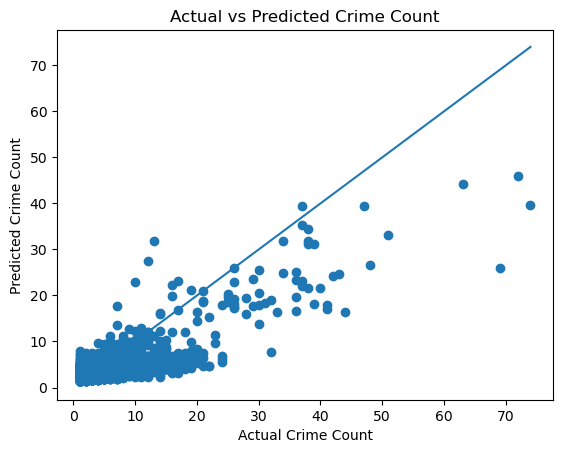

In [12]:

# Get best model from grid search results
best_model = grid_search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R^2 Score: {r2:.2f}")

# Plot: Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Actual vs Predicted Crime Count")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

We applied a Random Forest regression model to predict crime counts using historical data based on features such as location (sector and community), temporal variables (year and month), population information (resident_count), and crime category. Since the goal is to estimate the number of crimes for a specific type in a given area and time, the crime category was included as an input feature. The goal is to predict the number of crimes (crime count) for a specific crime type in a specific location at a specific time. Categorical features were transformed using One-Hot Encoding to convert them into a numerical format suitable for the model. A pipeline and column transformer were used to ensure consistent preprocessing and proper handling of different feature types. The dataset was split into training and testing sets, allowing the model to learn patterns from past data and be evaluated on unseen data. The Random Forest model works by constructing multiple decision trees using random subsets of the data and features, and then averaging their predictions to produce a final output. This allows the model to capture complex, non-linear relationships in the data while reducing overfitting. To improve performance, we applied GridSearchCV with 3-fold cross-validation to tune key hyperparameters such as the number of trees, maximum tree depth, and minimum samples per leaf. This systematic tuning process allowed us to identify a more optimal model configuration.

The final model achieved a Mean Squared Error of approximately 5.45, a Root Mean Squared Error of 2.33, a Mean Absolute Error of 1.47, and an R² score of 0.56. This represents a significant improvement over the initial model and indicates that the model explains 56% of the variability in crime counts. The prediction vs. actual plot shows a clear positive trend, with predictions reasonably close to the ideal line, although some underestimation still occurs at higher crime counts.

These results suggest that the selected features, like the inclusion of crime category provides meaningful predictive power. However, some variability remains unexplained, likely due to missing external factors such as weather, special events, or socioeconomic conditions. 

# 6.) Model 2 - Lasso Regression

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso

# Define feature types

# Categorical features (text-based → need encoding)
categorical_features = ["sector", "community_name", "category", "month"]

# Numerical features (already numeric)
numerical_features = ["year", "resident_count"]



# Preprocessing step

# ColumnTransformer applies different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        # Convert categorical variables into numerical format using One-Hot Encoding
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        
        # Scale numerical features
        ("num", StandardScaler(), numerical_features)
    ]
)



# Build the full pipeline

# Pipeline ensures preprocessing and model training happen together consistently
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),  # Step 1: transform input data
    
    ("model", Lasso(max_iter=10000))
])

In [14]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid (values we want to test)
param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],       # Regularization parameter alpha
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    lasso_model,       # The pipeline (includes preprocessing + lasso regression model)
    param_grid,        # Hyperparameter combinations to evaluate
    cv=5,              # 5-fold cross-validation (splits training data into 5 parts)
    scoring="r2",      # Evaluation metric (R² for regression performance)
    n_jobs=-1          # Use all available CPU cores for faster computation
)

# Train models for all parameter combinations
grid_search.fit(X_train, y_train)

# Output the best hyperparameters found
print("Best Parameters:", grid_search.best_params_)

# Output the best average cross-validation score
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'model__alpha': 0.001}
Best CV Score: 0.37497755851276404


# 7.) Predictions and Scores

Mean Squared Error (MSE): 7.78
Root Mean Squared Error (RMSE): 2.79
Mean Absolute Error (MAE): 1.63
R^2 Score: 0.37


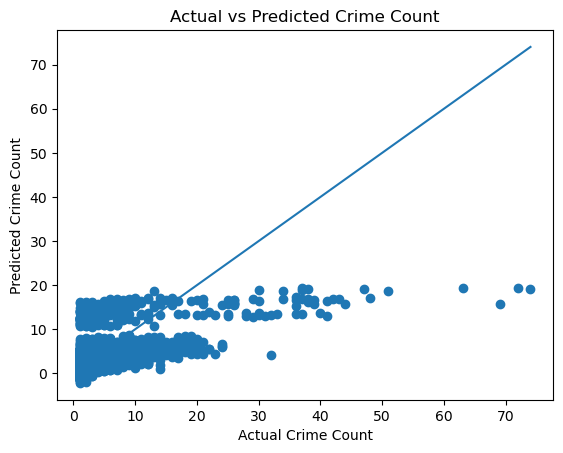

In [15]:
# Get best model from grid search results
best_model = grid_search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R^2 Score: {r2:.2f}")

# Plot: Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Actual vs Predicted Crime Count")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

# 8.) Model 3 - Gradient Boosted Regression Trees

In [16]:
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Define feature types

# Categorical features (text-based → need encoding)
categorical_features = ["sector", "community_name", "category", "month"]

# Numerical features (already numeric)
numerical_features = ["year", "resident_count"]


# Preprocessing step

# ColumnTransformer applies different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        # Convert categorical variables into numerical format using One-Hot Encoding
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        
        # Keep numerical features as they are (no scaling needed for Random Forest)
        ("num", "passthrough", numerical_features)
    ]
)

# Build the full pipeline
gbr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),  # Step 1: transform input data 
    ("model", GradientBoostingRegressor(
        n_estimators=200,       # Number of boosting stages (trees)
        learning_rate=0.1,     # Step size shrinkage (controls contribution of each tree)
        max_depth=5,           # Maximum depth of each tree (controls overfitting)
        min_samples_leaf=2,    # Minimum samples in a leaf → smoother predictions
        max_features="sqrt",   # Random subset of features at each split → increases diversity
        random_state=42         # Ensures reproducibility of results
    ))])
    


In [20]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid (values we want to test)
param_grid = {
    "model__n_estimators": [100, 200, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_samples_leaf": [1, 2, 5],
    "model__subsample": [0.8, 1.0],
    "model__max_features": ["sqrt"],
}

# Initialize GridSearchCV
grid_search_gbr = GridSearchCV(
    gbr_model,         # The pipeline (includes preprocessing + Gradient Boosting model)
    param_grid,        # Hyperparameter combinations to evaluate
    cv=3,              # 3-fold cross-validation (splits training data into 3 parts)
    scoring="r2",      # Evaluation metric (R² for regression performance)
    n_jobs=-1          # Use all available CPU cores for faster computation
)
# Train models for all parameter combinations
grid_search_gbr.fit(X_train, y_train)   
# Output the best hyperparameters found
print("Best Parameters:", grid_search_gbr.best_params_) 
# Output the best average cross-validation score
print("Best CV Score:", grid_search_gbr.best_score_)    




Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 400, 'model__subsample': 0.8}
Best CV Score: 0.6579076195366368


# 9.) Predictions and Scores

Mean Squared Error (MSE): 4.35
Root Mean Squared Error (RMSE): 2.09
Mean Absolute Error (MAE): 1.31
R^2 Score: 0.65


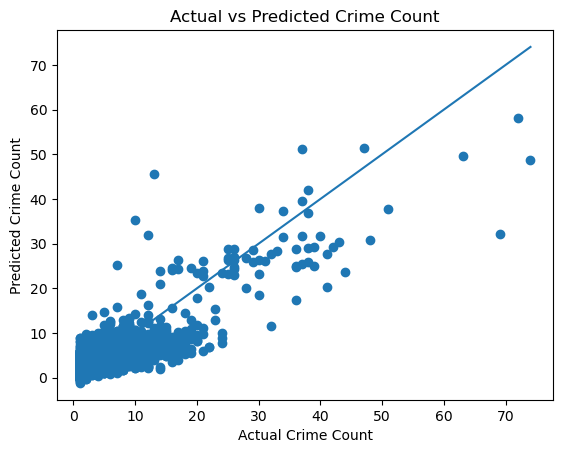

In [21]:
best_model_gbr = grid_search_gbr.best_estimator_

# Make predictions
y_pred = best_model_gbr.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# Print results
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R^2 Score: {r2:.2f}")
# Plot: Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Actual vs Predicted Crime Count")
# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()

### Classification Model

In [24]:
# Aggregate total crimes per community per month
df_agg = df.groupby(["sector", "community_name", "resident_count", "year", "month"], 
                     as_index=False)["crime_count"].sum()

df_agg = df_agg.rename(columns={"crime_count": "total_crime"})

# Create 3-class label: 0 = low-risk, 1 = medium-risk, 2 = high-risk
low_threshold = df_agg["total_crime"].quantile(0.33)
high_threshold = df_agg["total_crime"].quantile(0.66)

def label_risk(count):
    if count <= low_threshold:
        return 0  # low
    elif count <= high_threshold:
        return 1  # medium
    else:
        return 2  # high

df_agg["risk_level"] = df_agg["total_crime"].apply(label_risk)

print(f"Thresholds — Low: <={low_threshold}, Medium: <={high_threshold}, High: >{high_threshold}")
print(f"\nClass distribution:\n{df_agg['risk_level'].value_counts().sort_index()}")
print(f"\nAggregated dataset shape: {df_agg.shape}")
df_agg.head()


Thresholds — Low: <=5.0, Medium: <=12.0, High: >12.0

Class distribution:
risk_level
0    6754
1    5040
2    5388
Name: count, dtype: int64

Aggregated dataset shape: (17182, 7)


,sector,community_name,resident_count,year,month,total_crime,risk_level
0,CENTRE,ALTADORE,6942.0,2018,APR,11,1
1,CENTRE,ALTADORE,6942.0,2018,AUG,20,2
2,CENTRE,ALTADORE,6942.0,2018,DEC,10,1
3,CENTRE,ALTADORE,6942.0,2018,FEB,9,1
4,CENTRE,ALTADORE,6942.0,2018,JAN,10,1


In [25]:
#Features and target
features = ["sector", "community_name", "resident_count", "year", "month"]
target = "risk_level"

X = df_agg[features]
y = df_agg[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)  # Stratify to maintain class distribution in splits
print(f"Training set class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTesting set class distribution:\n{y_test.value_counts().sort_index()}")

Training set class distribution:
risk_level
0    5403
1    4032
2    4310
Name: count, dtype: int64

Testing set class distribution:
risk_level
0    1351
1    1008
2    1078
Name: count, dtype: int64


In [26]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, roc_curve, auc

categorical_features = ["sector", "community_name", "month"]
numerical_features = ["resident_count", "year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

# 1.) Logistic Regression

In [27]:
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sector', 'community_name',
                                                   'month']),
                                                 ('num', StandardScaler(),
                                                  ['resident_count',
                                                   'year'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [34]:
#Define hyperparameters for grid search
param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10, 100],  # Regularization strength (inverse of lambda)
    "model__penalty": ["l1", "l2"],             # Type of regularization (L1 = Lasso, L2 = Ridge)
    "model__solver": ["liblinear"]  # Solver that supports both L1 and L2 regularization
}

grid_search_lr = GridSearchCV(
    lr_model,
    param_grid_lr,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search_lr.fit(X_train, y_train)

print("Best Parameters:", grid_search_lr.best_params_)

print("Best CV Score:", grid_search_lr.best_score_)



Best Parameters: {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV Score: 0.7192277762075246


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.78      0.78      1351
           1       0.55      0.54      0.55      1008
           2       0.81      0.83      0.82      1078

    accuracy                           0.73      3437
   macro avg       0.72      0.72      0.72      3437
weighted avg       0.72      0.73      0.73      3437

Accuracy: 0.7256328193191737


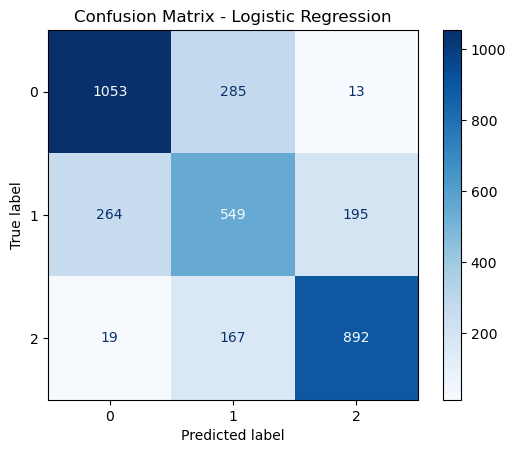

In [ ]:

best_model_lr = grid_search_lr.best_estimator_

y_pred_lr = best_model_lr.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model_lr.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()



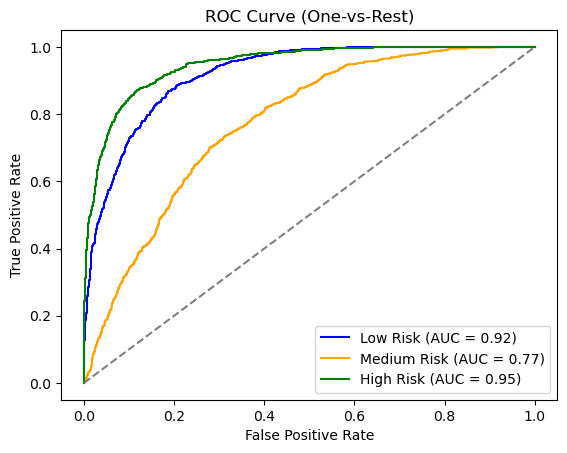

In [43]:
from sklearn.preprocessing import label_binarize

# Binarize the true labels (one column per class)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get predicted probabilities for each class
y_prob = best_model_lr.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure()
colors = ["blue", "orange", "green"]
labels = ["Low Risk", "Medium Risk", "High Risk"]

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

# 2.) Random Forest Classifier

In [ ]:
rfc_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42
    ))
])

rfc_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sector', 'community_name',
                                                   'month']),
                                                 ('num', StandardScaler(),
                                                  ['resident_count',
                                                   'year'])])),
                ('model',
                 RandomForestClassifier(max_depth=15, min_samples_leaf=2,
                                        n_estimators=200, random_state=42))])

In [ ]:
param_grid_rfc = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 15, 20],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"]
}

grid_search_rfc = GridSearchCV(
    rfc_model,
    param_grid_rfc,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search_rfc.fit(X_train, y_train)

print("Best Parameters:", grid_search_rfc.best_params_)

print("Best CV Score:", grid_search_rfc.best_score_)

Best Parameters: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best CV Score: 0.6636264215308457


Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.85      0.77      1351
           1       0.51      0.35      0.42      1008
           2       0.79      0.80      0.79      1078

    accuracy                           0.69      3437
   macro avg       0.67      0.67      0.66      3437
weighted avg       0.67      0.69      0.67      3437

Accuracy: 0.6886819901076521


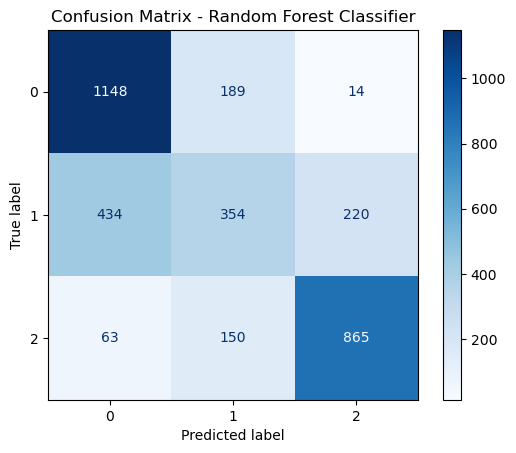

In [ ]:

best_rfc_model = grid_search_rfc.best_estimator_

y_pred_rfc = best_rfc_model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred_rfc))
print("Accuracy:", accuracy_score(y_test, y_pred_rfc))
cm = confusion_matrix(y_test, y_pred_rfc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rfc_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

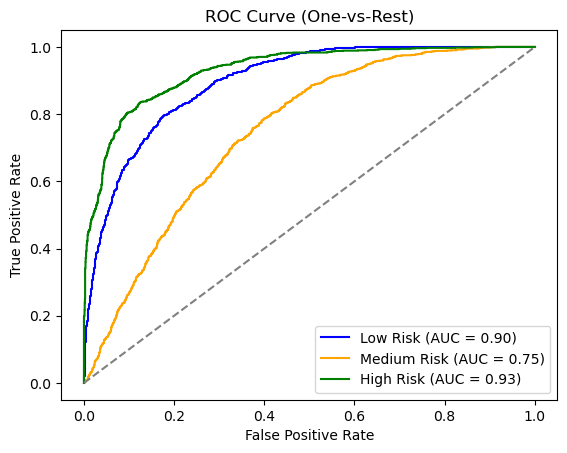

In [44]:
from sklearn.preprocessing import label_binarize

# Binarize the true labels (one column per class)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get predicted probabilities for each class
y_prob = best_rfc_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure()
colors = ["blue", "orange", "green"]
labels = ["Low Risk", "Medium Risk", "High Risk"]

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

# 3.) Gradient Boosted Classifer 

In [ ]:
gbc_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42
    ))
])

gbc_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sector', 'community_name',
                                                   'month']),
                                                 ('num', StandardScaler(),
                                                  ['resident_count',
                                                   'year'])])),
                ('model',
                 GradientBoostingClassifier(max_depth=5, max_features='sqrt',
                                            min_samples_leaf=2,
                                            n_estimators=200,
                                            random_state=42))])

In [45]:

param_grid_gbc = {
    "model__n_estimators": [100, 200, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_samples_leaf": [1, 2, 5],
    "model__subsample": [0.8, 1.0],
    "model__max_features": ["sqrt"],
}

grid_search_gbc = GridSearchCV(
    gbc_model,
    param_grid_gbc,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search_gbc.fit(X_train, y_train)

print("Best Parameters:", grid_search_gbc.best_params_)

print("Best CV Score:", grid_search_gbc.best_score_)



Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 400, 'model__subsample': 1.0}
Best CV Score: 0.7307475032700642


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.80      0.80      1351
           1       0.56      0.54      0.55      1008
           2       0.82      0.83      0.82      1078

    accuracy                           0.74      3437
   macro avg       0.72      0.73      0.72      3437
weighted avg       0.73      0.74      0.73      3437

Accuracy: 0.7352342158859471


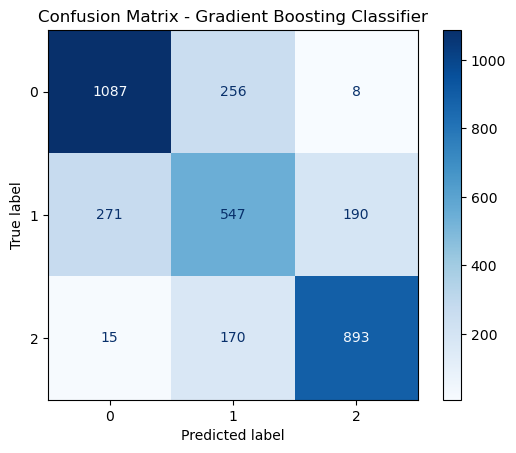

In [46]:

best_gbc_model = grid_search_gbc.best_estimator_

y_pred_gbc = best_gbc_model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred_gbc))
print("Accuracy:", accuracy_score(y_test, y_pred_gbc))
cm = confusion_matrix(y_test, y_pred_gbc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_gbc_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Gradient Boosting Classifier")
plt.show() 


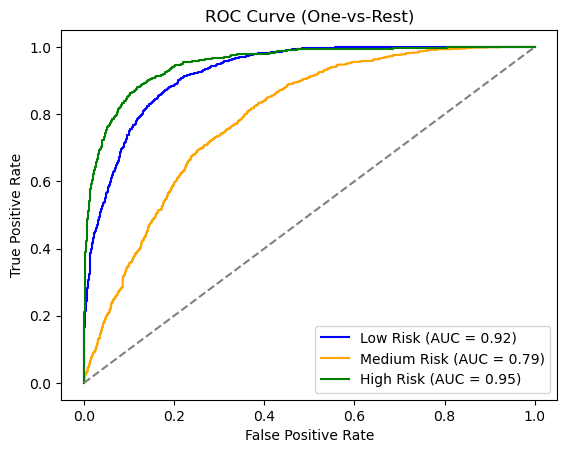

In [47]:
# Binarize the true labels (one column per class)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Get predicted probabilities for each class
y_prob = best_gbc_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure()
colors = ["blue", "orange", "green"]
labels = ["Low Risk", "Medium Risk", "High Risk"]

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # diagonal reference line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()